In [2]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score

df = pd.read_csv("/Users/erikwhiting/src/RNAFoldAssess/data/all_data/eterna_with_thresholds_and_auroc4.csv")

df

,model,auroc,eterna_0.10_0.00,eterna_0.11_0.00,eterna_0.12_0.00,eterna_0.12_0.01,eterna_0.13_0.00,eterna_0.13_0.01,eterna_0.13_0.02,eterna_0.13_0.03,...,eterna_0.99_0.80,eterna_0.99_0.81,eterna_0.99_0.82,eterna_0.99_0.83,eterna_0.99_0.84,eterna_0.99_0.85,eterna_0.99_0.86,eterna_0.99_0.87,eterna_0.99_0.88,eterna_0.99_0.89
0,NeuralFold,0.512633,0.077778,0.066667,0.044444,0.111111,0.044444,0.111111,0.211111,0.244444,...,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000
1,MXFold,0.752674,0.111111,0.100000,0.066667,0.166667,0.066667,0.166667,0.277778,0.355556,...,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111
2,NUPACK,0.663978,0.088889,0.088889,0.066667,0.155556,0.066667,0.155556,0.255556,0.322222,...,0.622222,0.622222,0.622222,0.622222,0.622222,0.622222,0.622222,0.622222,0.622222,0.622222
3,pKnots,0.601752,0.100000,0.088889,0.055556,0.144444,0.055556,0.144444,0.233333,0.288889,...,0.566667,0.566667,0.566667,0.566667,0.566667,0.566667,0.566667,0.566667,0.566667,0.566667
4,EternaFold,0.752674,0.111111,0.100000,0.066667,0.166667,0.066667,0.166667,0.277778,0.355556,...,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111
5,RNAFold,0.752674,0.111111,0.100000,0.066667,0.166667,0.066667,0.166667,0.277778,0.355556,...,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111
6,ContraFold,0.724046,0.111111,0.100000,0.066667,0.166667,0.066667,0.166667,0.266667,0.333333,...,0.488889,0.488889,0.488889,0.488889,0.488889,0.488889,0.488889,0.488889,0.488889,0.488889
7,MXFold2,0.752674,0.111111,0.100000,0.066667,0.166667,0.066667,0.166667,0.277778,0.355556,...,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111,0.511111
8,IPKnot,0.767955,0.155556,0.144444,0.111111,0.211111,0.111111,0.211111,0.311111,0.377778,...,0.433333,0.433333,0.433333,0.433333,0.433333,0.433333,0.433333,0.433333,0.433333,0.433333
9,SPOT-RNA,0.585626,0.100000,0.088889,0.055556,0.133333,0.055556,0.133333,0.200000,0.255556,...,0.466667,0.466667,0.466667,0.466667,0.466667,0.466667,0.466667,0.466667,0.466667,0.466667


In [3]:
threshold_cols = [
    col for col in df.columns
    if col.startswith("eterna_")
]

for col in threshold_cols:
    # Example column name: eterna_0.50_0.05
    _, unpaired_threshold, paired_threshold = col.split("_")

    sub = df[["auroc", col]].dropna()

    if len(sub) < 2:
        print(
            f"AUROC correlations with unpaired {unpaired_threshold}, paired {paired_threshold}:\n"
            f"    pearson: NA\n"
            f"    spearman: NA\n"
            f"    R^2: NA\n"
        )
        continue

    pearson_corr, _ = pearsonr(sub["auroc"], sub[col])
    spearman_corr, _ = spearmanr(sub["auroc"], sub[col])

    # R² as squared Pearson correlation
    r_squared = pearson_corr ** 2

    print(
        f"AUROC correlations with unpaired {unpaired_threshold}, paired {paired_threshold}:\n"
        f"    pearson: {pearson_corr:.4f}\n"
        f"    spearman: {spearman_corr:.4f}\n"
        f"    R^2: {r_squared:.4f}\n"
    )

AUROC correlations with unpaired 0.10, paired 0.00:
    pearson: 0.7056
    spearman: 0.9140
    R^2: 0.4979

AUROC correlations with unpaired 0.11, paired 0.00:
    pearson: 0.7118
    spearman: 0.9233
    R^2: 0.5067

AUROC correlations with unpaired 0.12, paired 0.00:
    pearson: 0.6406
    spearman: 0.8594
    R^2: 0.4104

AUROC correlations with unpaired 0.12, paired 0.01:
    pearson: 0.8702
    spearman: 0.9565
    R^2: 0.7572

AUROC correlations with unpaired 0.13, paired 0.00:
    pearson: 0.6406
    spearman: 0.8594
    R^2: 0.4104

AUROC correlations with unpaired 0.13, paired 0.01:
    pearson: 0.8702
    spearman: 0.9565
    R^2: 0.7572

AUROC correlations with unpaired 0.13, paired 0.02:
    pearson: 0.9073
    spearman: 0.9757
    R^2: 0.8232

AUROC correlations with unpaired 0.13, paired 0.03:
    pearson: 0.9769
    spearman: 0.9939
    R^2: 0.9543

AUROC correlations with unpaired 0.14, paired 0.00:
    pearson: 0.7121
    spearman: 0.8594
    R^2: 0.5071

AUROC corr

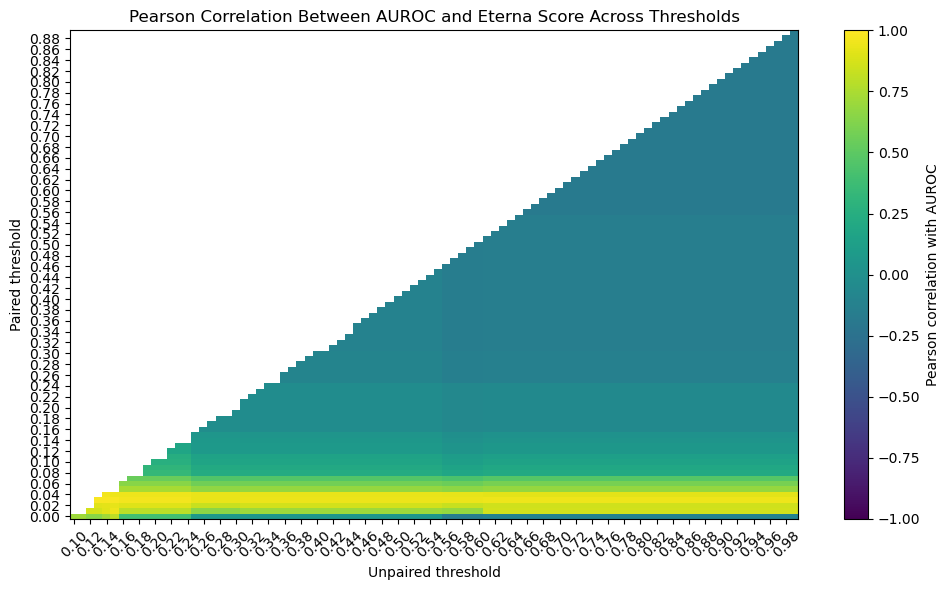

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df = pd.read_csv("/Users/erikwhiting/src/RNAFoldAssess/data/all_data/eterna_with_thresholds_and_auroc4.csv")

threshold_cols = [
    col for col in df.columns
    if col.startswith("eterna_")
]

rows = []

for col in threshold_cols:
    # Example: eterna_0.50_0.05
    _, unpaired_threshold, paired_threshold = col.split("_")

    sub = df[["auroc", col]].dropna()

    if len(sub) < 2:
        pearson_corr = None
    else:
        pearson_corr, _ = pearsonr(sub["auroc"], sub[col])

    rows.append({
        "unpaired_threshold": float(unpaired_threshold),
        "paired_threshold": float(paired_threshold),
        "pearson_corr": pearson_corr,
    })

corr_df = pd.DataFrame(rows)

heatmap_df = corr_df.pivot(
    index="paired_threshold",
    columns="unpaired_threshold",
    values="pearson_corr"
)

heatmap_df = heatmap_df.sort_index(ascending=True)
heatmap_df = heatmap_df.sort_index(axis=1, ascending=True)

plt.figure(figsize=(10, 6))

plt.imshow(
    heatmap_df,
    aspect="auto",
    origin="lower",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Pearson correlation with AUROC")

x_tick_positions = range(0, len(heatmap_df.columns), 2)
y_tick_positions = range(0, len(heatmap_df.index), 2)

plt.xticks(
    ticks=x_tick_positions,
    labels=[f"{heatmap_df.columns[i]:.2f}" for i in x_tick_positions],
    rotation=45
)

plt.yticks(
    ticks=y_tick_positions,
    labels=[f"{heatmap_df.index[i]:.2f}" for i in y_tick_positions]
)

plt.xlabel("Unpaired threshold")
plt.ylabel("Paired threshold")
plt.title("Pearson Correlation Between AUROC and Eterna Score Across Thresholds")

plt.tight_layout()
plt.savefig("auroc_eterna_threshold_pearson_heatmap_all.png", dpi=500)
plt.show()

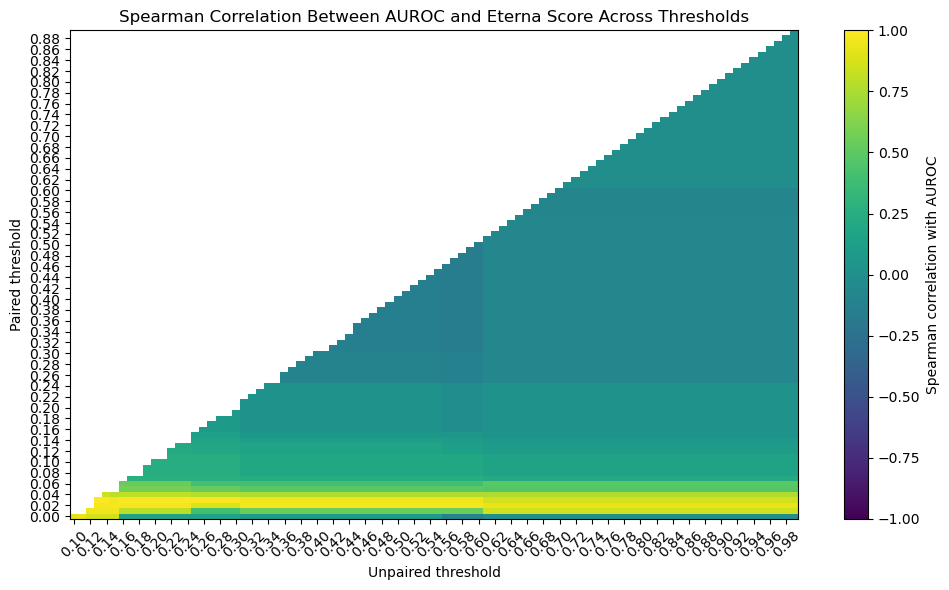

In [5]:
threshold_cols = [
    col for col in df.columns
    if col.startswith("eterna_")
]

rows = []

for col in threshold_cols:
    # Example: eterna_0.50_0.05
    _, unpaired_threshold, paired_threshold = col.split("_")

    sub = df[["auroc", col]].dropna()

    if len(sub) < 2:
        spearman_corr = None
    else:
        spearman_corr, _ = spearmanr(sub["auroc"], sub[col])

    rows.append({
        "unpaired_threshold": float(unpaired_threshold),
        "paired_threshold": float(paired_threshold),
        "spearman_corr": spearman_corr,
    })

corr_df = pd.DataFrame(rows)

heatmap_df = corr_df.pivot(
    index="paired_threshold",
    columns="unpaired_threshold",
    values="spearman_corr"
)

heatmap_df = heatmap_df.sort_index(ascending=True)
heatmap_df = heatmap_df.sort_index(axis=1, ascending=True)

plt.figure(figsize=(10, 6))

plt.imshow(
    heatmap_df,
    aspect="auto",
    origin="lower",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Spearman correlation with AUROC")

x_tick_positions = range(0, len(heatmap_df.columns), 2)
y_tick_positions = range(0, len(heatmap_df.index), 2)

plt.xticks(
    ticks=x_tick_positions,
    labels=[f"{heatmap_df.columns[i]:.2f}" for i in x_tick_positions],
    rotation=45
)

plt.yticks(
    ticks=y_tick_positions,
    labels=[f"{heatmap_df.index[i]:.2f}" for i in y_tick_positions]
)

plt.xlabel("Unpaired threshold")
plt.ylabel("Paired threshold")
plt.title("Spearman Correlation Between AUROC and Eterna Score Across Thresholds")

plt.tight_layout()
plt.savefig("auroc_eterna_threshold_spearman_heatmap_all.png", dpi=500)
plt.show()

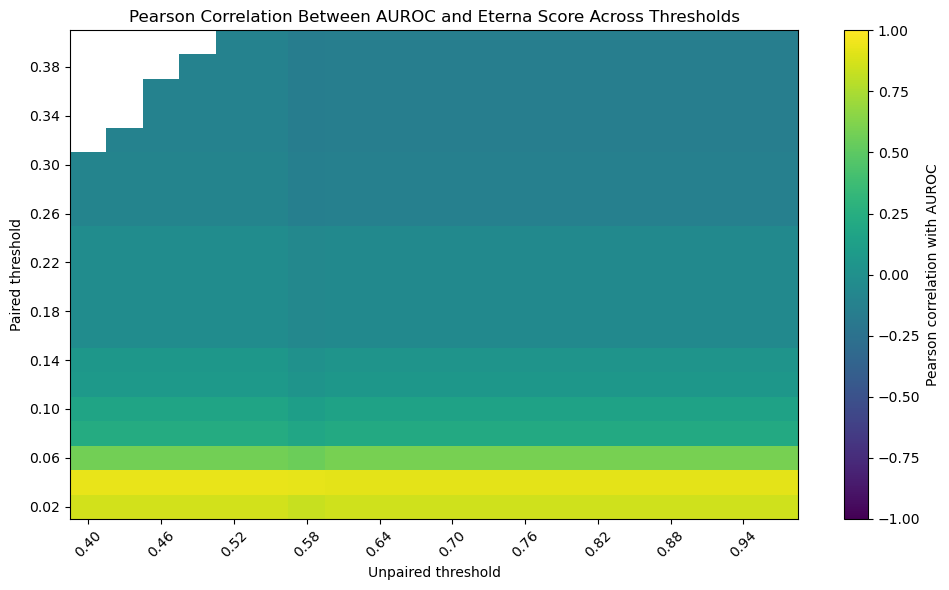

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df = pd.read_csv("/Users/erikwhiting/src/RNAFoldAssess/data/all_data/eterna_with_thresholds_and_auroc3.csv")

threshold_cols = [
    col for col in df.columns
    if col.startswith("eterna_")
]

rows = []

for col in threshold_cols:
    # Example: eterna_0.50_0.05
    _, unpaired_threshold, paired_threshold = col.split("_")

    sub = df[["auroc", col]].dropna()

    if len(sub) < 2:
        pearson_corr = None
    else:
        pearson_corr, _ = pearsonr(sub["auroc"], sub[col])

    rows.append({
        "unpaired_threshold": float(unpaired_threshold),
        "paired_threshold": float(paired_threshold),
        "pearson_corr": pearson_corr,
    })

corr_df = pd.DataFrame(rows)

heatmap_df = corr_df.pivot(
    index="paired_threshold",
    columns="unpaired_threshold",
    values="pearson_corr"
)

heatmap_df = heatmap_df.sort_index(ascending=True)
heatmap_df = heatmap_df.sort_index(axis=1, ascending=True)

plt.figure(figsize=(10, 6))

plt.imshow(
    heatmap_df,
    aspect="auto",
    origin="lower",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Pearson correlation with AUROC")

x_tick_positions = range(0, len(heatmap_df.columns), 2)
y_tick_positions = range(0, len(heatmap_df.index), 2)

plt.xticks(
    ticks=x_tick_positions,
    labels=[f"{heatmap_df.columns[i]:.2f}" for i in x_tick_positions],
    rotation=45
)

plt.yticks(
    ticks=y_tick_positions,
    labels=[f"{heatmap_df.index[i]:.2f}" for i in y_tick_positions]
)

plt.xlabel("Unpaired threshold")
plt.ylabel("Paired threshold")
plt.title("Pearson Correlation Between AUROC and Eterna Score Across Thresholds")

plt.tight_layout()
plt.savefig("auroc_eterna_threshold_pearson_heatmap.png", dpi=500)
plt.show()

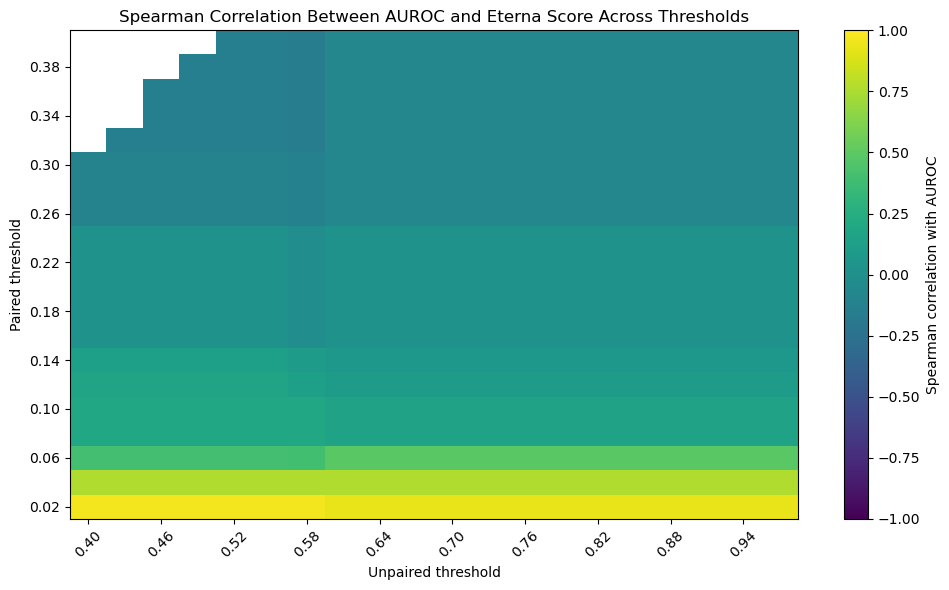

In [7]:
threshold_cols = [
    col for col in df.columns
    if col.startswith("eterna_")
]

rows = []

for col in threshold_cols:
    # Example: eterna_0.50_0.05
    _, unpaired_threshold, paired_threshold = col.split("_")

    sub = df[["auroc", col]].dropna()

    if len(sub) < 2:
        spearman_corr = None
    else:
        spearman_corr, _ = spearmanr(sub["auroc"], sub[col])

    rows.append({
        "unpaired_threshold": float(unpaired_threshold),
        "paired_threshold": float(paired_threshold),
        "spearman_corr": spearman_corr,
    })

corr_df = pd.DataFrame(rows)

heatmap_df = corr_df.pivot(
    index="paired_threshold",
    columns="unpaired_threshold",
    values="spearman_corr"
)

heatmap_df = heatmap_df.sort_index(ascending=True)
heatmap_df = heatmap_df.sort_index(axis=1, ascending=True)

plt.figure(figsize=(10, 6))

plt.imshow(
    heatmap_df,
    aspect="auto",
    origin="lower",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Spearman correlation with AUROC")

x_tick_positions = range(0, len(heatmap_df.columns), 2)
y_tick_positions = range(0, len(heatmap_df.index), 2)

plt.xticks(
    ticks=x_tick_positions,
    labels=[f"{heatmap_df.columns[i]:.2f}" for i in x_tick_positions],
    rotation=45
)

plt.yticks(
    ticks=y_tick_positions,
    labels=[f"{heatmap_df.index[i]:.2f}" for i in y_tick_positions]
)

plt.xlabel("Unpaired threshold")
plt.ylabel("Paired threshold")
plt.title("Spearman Correlation Between AUROC and Eterna Score Across Thresholds")

plt.tight_layout()
plt.savefig("auroc_eterna_threshold_spearman_heatmap.png", dpi=500)
plt.show()

AUROC correlations with unpaired 0.40, paired 0.02. r^2: 0.7496159718200203

AUROC correlations with unpaired 0.40, paired 0.04. r^2: 0.865264022326812

AUROC correlations with unpaired 0.40, paired 0.06. r^2: 0.3336359461995419

AUROC correlations with unpaired 0.40, paired 0.08. r^2: 0.05345462028829026

AUROC correlations with unpaired 0.40, paired 0.10. r^2: 0.027586520699143368

AUROC correlations with unpaired 0.40, paired 0.12. r^2: 0.006228166814102218

AUROC correlations with unpaired 0.40, paired 0.14. r^2: 0.003543706391763948

AUROC correlations with unpaired 0.40, paired 0.16. r^2: 0.0007141709094862047

AUROC correlations with unpaired 0.40, paired 0.18. r^2: 0.0007141709094862047

AUROC correlations with unpaired 0.40, paired 0.20. r^2: 0.0007141709094862047

AUROC correlations with unpaired 0.40, paired 0.22. r^2: 0.0007141709094862047

AUROC correlations with unpaired 0.40, paired 0.24. r^2: 0.0007141709094862047

AUROC correlations with unpaired 0.40, paired 0.26. r^2

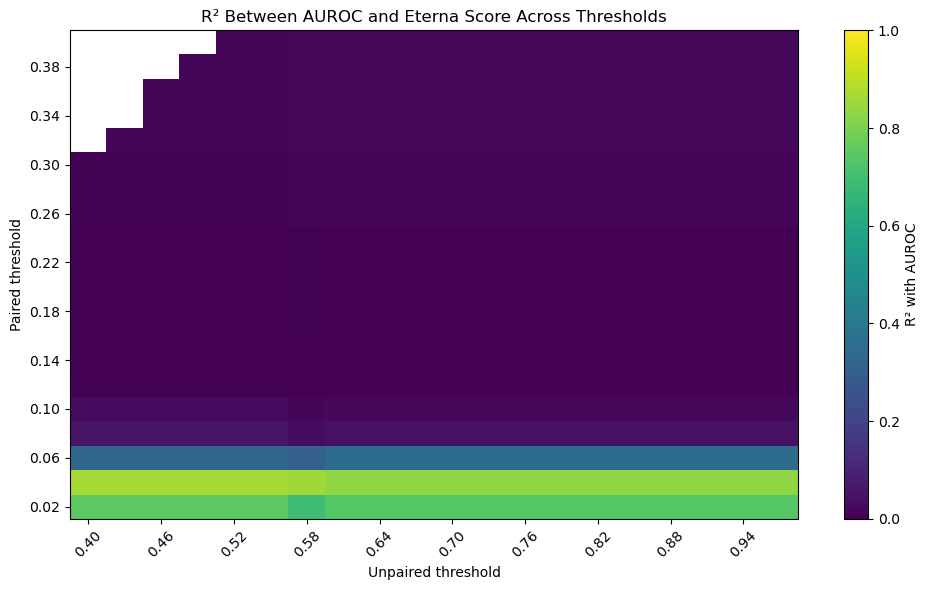

Highest r^2 is 0.865264022326812 for Unpaired threshold: 0.40, Paired threshold: 0.04


In [11]:
df = pd.read_csv("/Users/erikwhiting/src/RNAFoldAssess/data/all_data/eterna_with_thresholds_and_auroc3.csv")

vals = {}

from scipy.stats import pearsonr

threshold_cols = [
    col for col in df.columns
    if col.startswith("eterna_")
]

rows = []

for col in threshold_cols:
    # Example: eterna_0.50_0.05
    _, unpaired_threshold, paired_threshold = col.split("_")

    sub = df[["auroc", col]].dropna()

    if len(sub) < 2:
        r_squared = None
    else:
        pearson_corr, _ = pearsonr(sub["auroc"], sub[col])
        r_squared = pearson_corr ** 2

    rows.append({
        "unpaired_threshold": float(unpaired_threshold),
        "paired_threshold": float(paired_threshold),
        "r_squared": r_squared,
    })

    v_key = f"{unpaired_threshold}_{paired_threshold}"
    vals[v_key] = r_squared
    print(f"AUROC correlations with unpaired {unpaired_threshold}, paired {paired_threshold}. r^2: {r_squared}\n")


corr_df = pd.DataFrame(rows)

heatmap_df = corr_df.pivot(
    index="paired_threshold",
    columns="unpaired_threshold",
    values="r_squared"
)

heatmap_df = heatmap_df.sort_index(ascending=True)
heatmap_df = heatmap_df.sort_index(axis=1, ascending=True)

plt.figure(figsize=(10, 6))

plt.imshow(
    heatmap_df,
    aspect="auto",
    origin="lower",
    cmap="viridis",
    vmin=0,
    vmax=1
)

plt.colorbar(label="R² with AUROC")

x_tick_positions = range(0, len(heatmap_df.columns), 2)
y_tick_positions = range(0, len(heatmap_df.index), 2)

plt.xticks(
    ticks=x_tick_positions,
    labels=[f"{heatmap_df.columns[i]:.2f}" for i in x_tick_positions],
    rotation=45
)

plt.yticks(
    ticks=y_tick_positions,
    labels=[f"{heatmap_df.index[i]:.2f}" for i in y_tick_positions]
)

plt.xlabel("Unpaired threshold")
plt.ylabel("Paired threshold")
plt.title("R² Between AUROC and Eterna Score Across Thresholds")

plt.tight_layout()
plt.savefig("auroc_eterna_threshold_r_squared_heatmap.png", dpi=500)
plt.show()

highest_val = max(vals.values())
highest_key = max(vals, key=vals.get)
upt, pt = highest_key.split("_")

print(f"Highest r^2 is {highest_val} for Unpaired threshold: {upt}, Paired threshold: {pt}")